# Tutorial:Variational Quantum Eigensolver with Reinforcement Learning (RL)   
### Estimating the Ground State Energy of the Hydrogen Molecule ($H_2$)


In this hands-on tutorial, we demonstrate how to implement RL to estimate the ground state energy $E_0$ of the hydrogen molecule ($H_2$). We explore two different approaches: RL algorithms: **PPO** (on-policy) and **TD3** (off-policy).


Both approaches aim to efficiently find the optimal parameters for the Variational Quantum Eigensolver (VQE) using RL.

We begin by importing the necessary libraries. In particular:

-    create_circuit_ansatz: A customizable function to generate the parameterized quantum circuit (ansatz).


Note: The hyperparameters that you will find in this notebook have not been optimised.

In [1]:
import numpy as np
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(parent_dir, 'src/utils/'))
sys.path.append(os.path.join(parent_dir, 'src/rl/'))
from functions import CustomEncoder
from circuit_utils import create_circuit_ansatz
utils_path = os.path.abspath(os.path.join(parent_dir, '../src/'))
sys.path.append(utils_path)
import json
from optimisation_rl import RLQuantumOptimiserPPO, RLQuantumOptimiserTD3

from scipy.linalg import eigh
from qiskit.quantum_info import Statevector
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.operators import PolynomialTensor
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import TwoLocal

## Setting Up the Molecular Hamiltonian for $H_2$

In the next section, we define the $H_2$ molecule and construct its corresponding qubit Hamiltonian, which will later be used in the VQE algorithm.

1. Molecular Setup: <br /> 
    We use the PySCFDriver from Qiskit Nature to define the $H_2$ molecule at an internuclear distance of 0.735 Å, with a minimal basis set (sto3g), zero charge, and zero spin.
2. Hamiltonian Construction: <br /> 
    Running the driver yields the electronic structure problem, from which we extract the second-quantized electronic Hamiltonian.

3. Mapping to Qubits: <br /> 
    The fermionic Hamiltonian is mapped to a qubit Hamiltonian using the Jordan-Wigner transformation, enabling its simulation on a quantum computer.

4. Including Nuclear Repulsion Energy: <br /> 
    We add the nuclear repulsion energy to the electronic part of the Hamiltonian to obtain the total molecular energy. The Hamiltonian is then updated and remapped to qubits.

This qubit Hamiltonian, H, will serve as the objective function in our variational quantum algorithm.

In [2]:
#Setting up the H2 molecule
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)


problem = driver.run()

#Obtaining the Hamiltonian
hamiltonian = problem.hamiltonian
hamiltonian.electronic_integrals.alpha += PolynomialTensor({"": hamiltonian.nuclear_repulsion_energy})

mapper = JordanWignerMapper()
second_q_op = hamiltonian.second_q_op()
H = mapper.map(second_q_op)



## Building the Variational Ansatz for the $H_2$ Molecule

In this section, we define the quantum circuit that prepares the trial wavefunction used in the VQE.

1.  Initial State – Hartree-Fock:
    We prepare the Hartree-Fock (HF) state using the HartreeFock class, which represents the mean-field approximation of the ground state. It is constructed based on:

    -    The number of spatial orbitals

    -    The number of particles (electrons)

    -    The chosen qubit mapping (Jordan-Wigner in this case)

2.  Ansatz Options:
    Two variational forms are considered for preparing the quantum state:

    -    UCCSD (Unitary Coupled Cluster with Singles and Doubles): A chemically inspired ansatz tailored to quantum chemistry problems.

    -    TwoLocal Ansatz: A hardware-efficient, generic ansatz composed of parameterized single-qubit rotations (ry) and entangling gates (cz).


3.  Visualization and Parameters:

    -    The number of qubits required is extracted from the ansatz.

    -    We print and visualize the initial Hartree-Fock state.

    -    We visualize the parameterized circuit (ansatz) using a helper function create_circuit_ansatz, initialized with zero parameters.

This variational form will be optimized to minimize the expectation value of the qubit Hamiltonian, leading us to the ground state energy of the molecule.


Initial state: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2))
Circuit Ansatz
n_thetas: 3


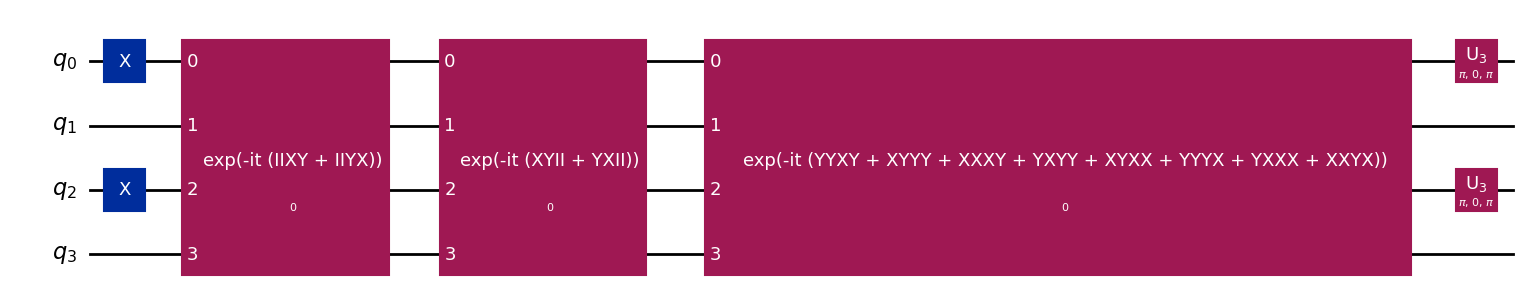

In [3]:
# Set up the initial state and, the UCCSD or TwoLocal ansatz for H2
num_spatial_orbitals = problem.num_spatial_orbitals
num_particles = problem.num_particles
mapper = JordanWignerMapper()

initial_state = HartreeFock(
    num_spatial_orbitals,
    num_particles,
    mapper
)

ansatz = UCCSD(num_spatial_orbitals=num_spatial_orbitals, num_particles=num_particles, qubit_mapper=mapper, initial_state=initial_state, reps=1)
#ansatz = TwoLocal(H.num_qubits, rotation_blocks="ry", entanglement_blocks="cz")
num_qubits = ansatz.num_qubits

print('Initial state:', Statevector.from_instruction(initial_state))
initial_circuit = ansatz.decompose()
print('Circuit Ansatz')
n_thetas = ansatz.num_parameters
print("n_thetas:", n_thetas)
circ_visualization = create_circuit_ansatz(ansatz, np.zeros(n_thetas)[np.newaxis,:], initial_state)
circ_visualization.decompose().draw('mpl')


## Exact Diagonalization of the Qubit Hamiltonian

Before applying VQE, we compute the exact ground state energy of the system using classical diagonalization. This serves as a reference to evaluate the performance of our variational method.


In [4]:
eigenvalues, eigenvectors = eigh(H.to_matrix())
ground_state_energy = np.min(eigenvalues)
ground_state = eigenvectors[:, np.argmin(eigenvalues)]
print(f"Ground state energy: {ground_state_energy}")

Ground state energy: -1.1373060357534004


## Optimising the Ground State Energy – PPO


In this section, we perform VQE using PPO


In [5]:
hyperparams = {'learning_rate': 0.001,
          'n_steps': 20,
          'batch_size':10,
          'gae_lambda': 0.95,
          'gamma':0.99,  
          'ent_coef':0.01,
          'clip_range':0.3,
          'total_timesteps': 200,
          'n_epochs': 20
          }

n_run = 3

metrics = {'history_best_eigenvalue_runs':[],
           'history_best_thetas_runs':[],
           'best_eigenvalue_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)

    optimiser = RLQuantumOptimiserPPO(create_circuit_ansatz, 
                                ansatz=ansatz,
                                n_thetas=n_thetas, 
                                initial_state=initial_state, 
                                H=H, 
                                num_qubits=num_qubits,
                                hyperparams=hyperparams)
    
    # Run optimisation
    optimal_params, eigenvalue, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal eigenvalue found:", eigenvalue)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_eigenvalue = np.array(info['best_log']['eigenvalue'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_eigenvalue_runs'].append(log_best_eigenvalue)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_eigenvalue_runs'].append(eigenvalue)
    


run  1
Optimal parameters found: [0.        0.        1.7202924]
Optimal eigenvalue found: -0.9294938790038489
run  2
Optimal parameters found: [0.        0.        1.3087906]
Optimal eigenvalue found: -0.9198711939528055
run  3
Optimal parameters found: [0.        0.        1.5527462]
Optimal eigenvalue found: -0.934177426903375


We can save our results for later analysis

In [6]:

if True:
    name_output_file = "example_results_H2_ppo"
    
    data_plot = {'history_best_eigenvalue_runs':metrics['history_best_eigenvalue_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_eigenvalue_runs':metrics['best_eigenvalue_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)


We plot the results for PPO

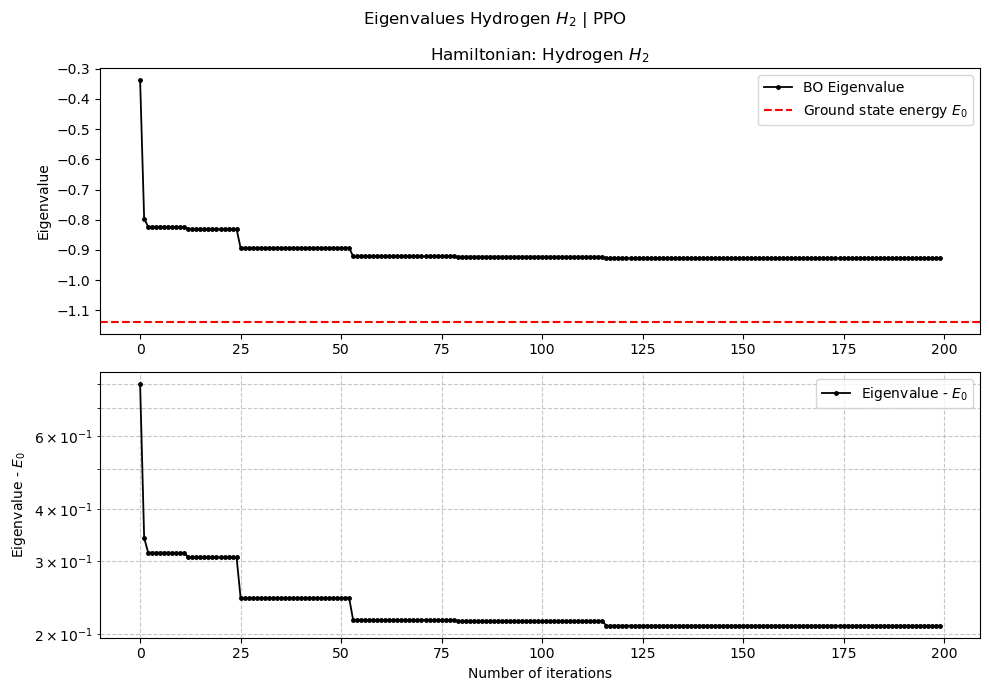

Mean Best Eigenvalue:  -0.9278474999533431


In [7]:
import matplotlib.pylab as plt

fig, ax = plt.subplots(2,1,figsize=(10,7), facecolor='white', constrained_layout = True, sharex=False, sharey=False)

plt.suptitle('Eigenvalues Hydrogen $H_{2}$ | PPO')

ax[0].set_title(r'Hamiltonian: Hydrogen $H_{2}$')
ax[0].plot(np.arange(hyperparams['total_timesteps'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0), '-o', linewidth=1.3, color='k', markersize=2.5, label = 'BO Eigenvalue')
ax[0].axhline(ground_state_energy, linestyle='--',color='r', label='Ground state energy $E_{0}$')

ax[1].plot(np.arange(hyperparams['total_timesteps'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0) - ground_state_energy, '-o', linewidth=1.3, color='k', markersize=2.5, label = 'Eigenvalue - $E_{0}$')
ax[1].set_yscale('log')
ax[0].set_ylabel('Eigenvalue')
ax[1].set_ylabel('Eigenvalue - $E_{0}$')
ax[1].set_xlabel('Number of iterations')

ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()
print('Mean Best Eigenvalue: ', np.mean(metrics['best_eigenvalue_runs']))



## Optimising the Ground State Energy – TD3


Next, we apply the same process to the TD3 algorithm. We define the necessary hyperparameters and specify the number of runs for the same architecture to ensure consistency in our results.  

In [8]:
hyperparams = {'learning_rate': 0.001,
          'batch_size':10,
          'gamma':0.99,  
          'noise_std': 0.001,
          'total_timesteps': 200,
          'verbose': 0
          }


n_run = 3

metrics = {'history_best_eigenvalue_runs':[],
           'history_best_thetas_runs':[],
           'best_eigenvalue_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)

    optimiser = RLQuantumOptimiserTD3(create_circuit_ansatz, 
                                    ansatz=ansatz,
                                    n_thetas=n_thetas, 
                                    initial_state=initial_state, 
                                    H=H, 
                                    num_qubits=num_qubits,
                                    hyperparams=hyperparams)

    # Run optimisation
    optimal_params, eigenvalue, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal eigenvalue found:", eigenvalue)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_eigenvalue = np.array(info['best_log']['eigenvalue'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_eigenvalue_runs'].append(log_best_eigenvalue)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_eigenvalue_runs'].append(eigenvalue)
    
   

run  1
Optimal parameters found: [6.188686 6.224698 4.632865]
Optimal eigenvalue found: -0.9152060710766944
run  2
Optimal parameters found: [0.2594993  0.08911114 1.4066768 ]
Optimal eigenvalue found: -0.8242693204437439
run  3
Optimal parameters found: [0.01290645 3.2350752  2.0995824 ]
Optimal eigenvalue found: -0.8670216085232865


In [9]:
if True:
    name_output_file = "example_results_H2_td3"
    
    data_plot = {'history_best_eigenvalue_runs':metrics['history_best_eigenvalue_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_eigenvalue_runs':metrics['best_eigenvalue_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)



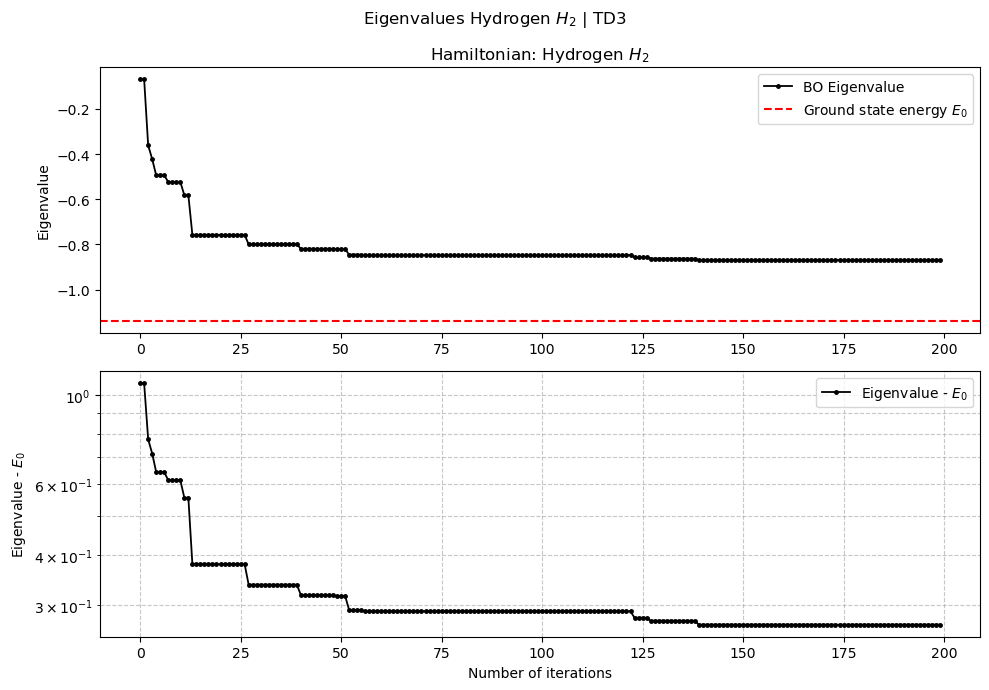

Mean Best Eigenvalue:  -0.8688323333479083


In [10]:
import matplotlib.pylab as plt

fig, ax = plt.subplots(2,1,figsize=(10,7), facecolor='white', constrained_layout = True, sharex=False, sharey=False)

plt.suptitle('Eigenvalues Hydrogen $H_{2}$ | TD3')

ax[0].set_title(r'Hamiltonian: Hydrogen $H_{2}$')
ax[0].plot(np.arange(hyperparams['total_timesteps'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0), '-o', linewidth=1.3, color='k', markersize=2.5, label = 'BO Eigenvalue')
ax[0].axhline(ground_state_energy, linestyle='--',color='r', label='Ground state energy $E_{0}$')

ax[1].plot(np.arange(hyperparams['total_timesteps'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0) - ground_state_energy, '-o', linewidth=1.3, color='k', markersize=2.5, label = 'Eigenvalue - $E_{0}$')
ax[1].set_yscale('log')
ax[0].set_ylabel('Eigenvalue')
ax[1].set_ylabel('Eigenvalue - $E_{0}$')
ax[1].set_xlabel('Number of iterations')

ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()
print('Mean Best Eigenvalue: ', np.mean(metrics['best_eigenvalue_runs']))